# 📊 F1 Raw Data Profiling
**Mục tiêu:** Phân tích dữ liệu thô SAU khi crawl, TRƯỚC khi clean — để đưa ra chiến lược cleaning đúng.

### 7 Kỹ thuật áp dụng:
1. Data Consolidation & Unification
2. Data Profiling (Descriptive Stats)
3. Data Sanitization (Invalid values, whitespace)
4. Low Variance Filtering (99% threshold)
5. Missing Value Analysis & Visualization
6. Deduplication Check
7. Datetime Feature Detection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='darkgrid', palette='muted')

RAW_DIR = Path('../data/raw')
LOW_VARIANCE_THRESHOLD = 0.99   # Cột có >99% cùng giá trị → loại
HIGH_MISSING_THRESHOLD = 0.20   # Cột có >20% null → cân nhắc drop
print('Setup OK ✅')

Setup OK ✅


---
## 1️⃣ Data Consolidation & Unification
Gộp tất cả session-based files của từng endpoint, kiểm tra Type Matching và Schema Alignment.

In [2]:
def load_endpoint(endpoint: str) -> pd.DataFrame:
    """Load và gộp tất cả file CSV/Parquet của một endpoint."""
    ep_dir = RAW_DIR / endpoint
    if not ep_dir.exists():
        return pd.DataFrame()
    files = list(ep_dir.glob('**/*.csv')) + list(ep_dir.glob('**/*.parquet'))
    if not files:
        return pd.DataFrame()

    frames = []
    schema_issues = []
    ref_dtypes = None
    ref_cols = None

    for f in files:
        df = pd.read_parquet(f) if f.suffix == '.parquet' else pd.read_csv(f, low_memory=False)
        if df.empty:
            continue

        # --- Kỹ thuật 1a: Schema Alignment ---
        if ref_cols is None:
            ref_cols = set(df.columns)
            ref_dtypes = df.dtypes
        else:
            extra = set(df.columns) - ref_cols
            missing = ref_cols - set(df.columns)
            if extra or missing:
                schema_issues.append({'file': f.name, 'extra_cols': list(extra), 'missing_cols': list(missing)})

            # --- Kỹ thuật 1b: Type Matching ---
            for col in ref_cols & set(df.columns):
                if ref_dtypes[col] != df[col].dtype:
                    schema_issues.append({'file': f.name, 'col': col,
                                          'expected': str(ref_dtypes[col]), 'got': str(df[col].dtype)})
        frames.append(df)

    if schema_issues:
        print(f'⚠️  Schema/Type issues in [{endpoint}]:')
        display(pd.DataFrame(schema_issues))

    combined = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    combined['_source_endpoint'] = endpoint
    return combined


# Load tất cả endpoints tìm thấy trong data/raw/
ENDPOINTS = [d.name for d in RAW_DIR.iterdir() if d.is_dir()]
print(f'Found endpoints: {ENDPOINTS}')

dfs = {}
for ep in ENDPOINTS:
    df = load_endpoint(ep)
    if not df.empty:
        dfs[ep] = df
        print(f'  ✅ {ep}: {len(df):,} rows × {len(df.columns)} cols')
    else:
        print(f'  ⚫ {ep}: no data')

Found endpoints: ['car_data', 'drivers', 'intervals', 'laps', 'location', 'meetings', 'overtakes', 'pit', 'position', 'race_control', 'sessions', 'session_result', 'starting_grid', 'stints', 'team_radio', 'weather']
  ✅ car_data: 85,151,808 rows × 23 cols
⚠️  Schema/Type issues in [drivers]:


,file,col,expected,got
0,10002.csv,country_code,object,float64
1,10006.csv,country_code,object,float64
2,10010.csv,country_code,object,float64
3,10014.csv,country_code,object,float64
4,10018.csv,country_code,object,float64
...,...,...,...,...
115,11420.csv,country_code,object,float64
116,11424.csv,country_code,object,float64
117,11428.csv,country_code,object,float64
118,11432.csv,country_code,object,float64


  ✅ drivers: 3,717 rows × 13 cols
⚠️  Schema/Type issues in [intervals]:


,file,col,expected,got
0,9506.csv,gap_to_leader,object,float64
1,9507.csv,gap_to_leader,object,float64
2,9515.csv,interval,float64,object
3,9523.csv,interval,float64,object
4,9531.csv,interval,float64,object
5,9549.csv,gap_to_leader,object,float64
6,9574.csv,gap_to_leader,object,float64
7,9582.csv,interval,float64,object
8,9616.csv,gap_to_leader,object,float64
9,9635.csv,gap_to_leader,object,float64


  ✅ intervals: 1,362,164 rows × 7 cols
⚠️  Schema/Type issues in [laps]:


...

  ✅ race_control: 9,253 rows × 12 cols
  ✅ sessions: 180 rows × 16 cols
⚠️  Schema/Type issues in [session_result]:


,file,extra_cols,missing_cols,col,expected,got
0,9472.csv,[points],[],NaN,NaN,NaN
1,9472.csv,NaN,NaN,duration,object,float64
2,9476.csv,NaN,NaN,position,int64,float64
3,9480.csv,[points],[],NaN,NaN,NaN
4,9480.csv,NaN,NaN,position,int64,float64
...,...,...,...,...,...,...
222,11275.csv,NaN,NaN,gap_to_leader,object,float64
223,11276.csv,NaN,NaN,position,int64,float64
224,11280.csv,[points],[],NaN,NaN,NaN
225,11280.csv,NaN,NaN,position,int64,float64


  ✅ session_result: 2,654 rows × 12 cols
  ✅ starting_grid: 1,311 rows × 6 cols
⚠️  Schema/Type issues in [stints]:


,file,col,expected,got
0,9496.csv,lap_start,int64,float64
1,9496.csv,lap_end,int64,float64
2,9506.csv,lap_start,int64,float64
3,9506.csv,lap_end,int64,float64
4,9523.csv,lap_start,int64,float64
5,9523.csv,lap_end,int64,float64
6,9558.csv,lap_start,int64,float64
7,9558.csv,lap_end,int64,float64
8,9625.csv,lap_start,int64,float64
9,9625.csv,lap_end,int64,float64


  ✅ stints: 8,919 rows × 9 cols
  ✅ team_radio: 5,773 rows × 6 cols
  ✅ weather: 14,513 rows × 11 cols


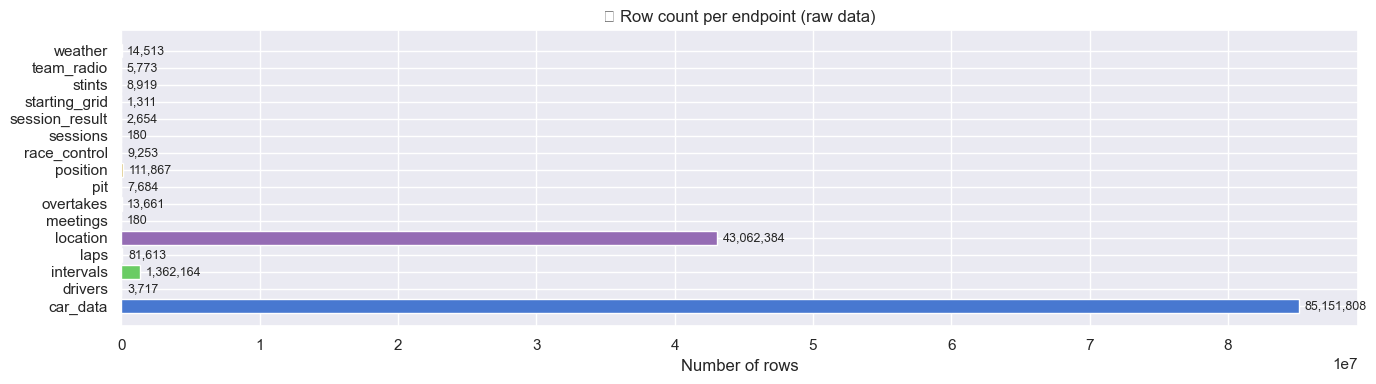

In [3]:
# Biểu đồ: số lượng dòng theo endpoint
sizes = {ep: len(df) for ep, df in dfs.items()}
fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.barh(list(sizes.keys()), list(sizes.values()), color=sns.color_palette('muted', len(sizes)))
ax.bar_label(bars, labels=[f'{v:,}' for v in sizes.values()], padding=4, fontsize=9)
ax.set_xlabel('Number of rows')
ax.set_title('📦 Row count per endpoint (raw data)')
plt.tight_layout()
plt.show()

---
## 2️⃣ Data Profiling — Descriptive Statistics & Unique Values
Chọn endpoint cần phân tích chi tiết bên dưới.

In [4]:
ENDPOINT_TO_PROFILE = 'laps'   # ← Đổi tên endpoint ở đây

if ENDPOINT_TO_PROFILE not in dfs:
    print(f'❌ Endpoint "{ENDPOINT_TO_PROFILE}" not loaded. Available: {list(dfs.keys())}')
else:
    df = dfs[ENDPOINT_TO_PROFILE].copy()

    print(f'=== [{ENDPOINT_TO_PROFILE}] Shape: {df.shape} ===')

    # Descriptive statistics
    print('\n--- Descriptive Statistics ---')
    display(df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['count']))

    # Unique value analysis
    print('\n--- Unique Value Analysis ---')
    unique_info = pd.DataFrame({
        'dtype': df.dtypes,
        'nunique': df.nunique(),
        'null_count': df.isnull().sum(),
        'null_%': (df.isnull().sum() / len(df) * 100).round(2),
        'sample_values': [df[c].dropna().unique()[:5].tolist() for c in df.columns]
    })
    unique_info['likely_type'] = unique_info.apply(
        lambda r: 'ID/Key' if r['nunique'] == len(df) else
                  'Categorical' if r['nunique'] < 30 else
                  'High-card text' if r['dtype'] == object else 'Numeric', axis=1
    )
    display(unique_info.style.background_gradient(cmap='Oranges', subset=['null_%']))


=== [laps] Shape: (81613, 17) ===

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
meeting_key,81613.000000,nan,nan,nan,1255.317143,15.680218,1229.000000,1241.000000,1255.000000,1269.000000,1284.000000
session_key,81613.000000,nan,nan,nan,9869.456533,450.775272,9468.000000,9582.000000,9841.000000,9959.000000,11280.000000
driver_number,81613.000000,nan,nan,nan,29.517650,24.505044,1.000000,11.000000,22.000000,44.000000,87.000000
lap_number,81613.000000,nan,nan,nan,24.056670,18.287386,1.000000,9.000000,19.000000,38.000000,78.000000
date_start,81500,80249,2026-03-29T05:14:02.078000+00:00,22,nan,nan,nan,nan,nan,nan,nan
duration_sector_1,76339.000000,nan,nan,nan,29.379457,8.052314,16.251000,25.421000,28.870000,32.286000,121.725000
duration_sector_2,81219.000000,nan,nan,nan,35.695619,8.348962,16.915000,29.619000,34.861000,41.425000,90.308000
duration_sector_3,80191.000000,nan,nan,nan,29.297047,8.995964,15.941000,23.307000,27.258000,33.527500,99.438000
i1_speed,71719.000000,nan,nan,nan,249.024233,48.808807,31.000000,213.000000,259.000000,287.000000,359.000000
i2_speed,80310.000000,nan,nan,nan,243.103138,49.413279,26.000000,205.000000,254.000000,280.000000,347.000000



--- Unique Value Analysis ---


,dtype,nunique,null_count,null_%,sample_values,likely_type
meeting_key,int64,52,0,0.000000,"[1229, 1230, 1231, 1232, 1234]",Numeric
session_key,int64,131,0,0.000000,"[9468, 9472, 9476, 9480, 9484]",Numeric
driver_number,int64,31,0,0.000000,"[55, 16, 31, 10, 23]",Numeric
lap_number,int64,78,0,0.000000,"[1, 2, 3, 4, 5]",Numeric
date_start,object,80249,113,0.140000,"['2024-03-01T16:00:16.716000+00:00', '2024-03-01T16:00:22.110000+00:00', '2024-03-01T16:00:24.082000+00:00', '2024-03-01T16:02:03.464000+00:00', '2024-03-01T16:02:12.573000+00:00']",High-card text
duration_sector_1,float64,24627,5274,6.460000,"[29.76, 29.522, 29.755, 29.87, 39.616]",Numeric
duration_sector_2,float64,27460,394,0.480000,"[47.556, 45.475, 48.58, 46.947, 38.878]",Numeric
duration_sector_3,float64,27347,1422,1.740000,"[25.067, 27.582, 25.377, 31.307, 22.57]",Numeric
i1_speed,float64,316,9894,12.120000,"[210.0, 219.0, 179.0, 197.0, 238.0]",Numeric
i2_speed,float64,307,1303,1.600000,"[231.0, 240.0, 218.0, 214.0, 273.0]",Numeric


---
## 3️⃣ Data Sanitization
### 3a. Giá trị phi lý (giá trị âm trong cột số)
### 3b. Whitespace detection

In [5]:
if ENDPOINT_TO_PROFILE in dfs:
    df = dfs[ENDPOINT_TO_PROFILE].copy()
    numeric_cols = df.select_dtypes(include='number').columns

    # 3a. Negative values
    neg_report = []
    for col in numeric_cols:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            neg_report.append({'column': col, 'negative_count': n_neg,
                                'pct': round(n_neg / len(df) * 100, 2),
                                'min_value': df[col].min()})

    if neg_report:
        print('⚠️  Negative values found:')
        display(pd.DataFrame(neg_report))
    else:
        print('✅ No negative values in numeric columns')

    # 3b. Whitespace-only strings
    ws_report = []
    for col in df.select_dtypes(include='object').columns:
        n_ws = df[col].astype(str).str.strip().eq('').sum()
        if n_ws > 0:
            ws_report.append({'column': col, 'blank_count': n_ws,
                               'pct': round(n_ws / len(df) * 100, 2)})

    if ws_report:
        print('\n⚠️  Whitespace/blank strings found:')
        display(pd.DataFrame(ws_report))
    else:
        print('✅ No whitespace-only strings')

✅ No negative values in numeric columns
✅ No whitespace-only strings


---
## 4️⃣ Low Variance Filtering (≥99% same value → useless column)

In [17]:
if ENDPOINT_TO_PROFILE in dfs:
    df = dfs[ENDPOINT_TO_PROFILE].copy()

    lv_report = []
    for col in df.columns:
        if col == '_source_endpoint':
            continue
        top_freq = df[col].value_counts(normalize=True, dropna=False).iloc[0]
        top_val = df[col].value_counts(dropna=False).index[0]
        if top_freq >= LOW_VARIANCE_THRESHOLD:
            lv_report.append({'column': col, 'dominant_value': top_val,
                               'dominance_%': round(top_freq * 100, 2)})

    if lv_report:
        print(f'⚠️  Low-variance columns (≥{LOW_VARIANCE_THRESHOLD*100:.0f}% same value) → candidate for DROP:')
        display(pd.DataFrame(lv_report).style.background_gradient(cmap='Reds', subset=['dominance_%']))
    else:
        print('✅ No low-variance columns found')

✅ No low-variance columns found


---
## 5️⃣ Missing Value Analysis & Visualization

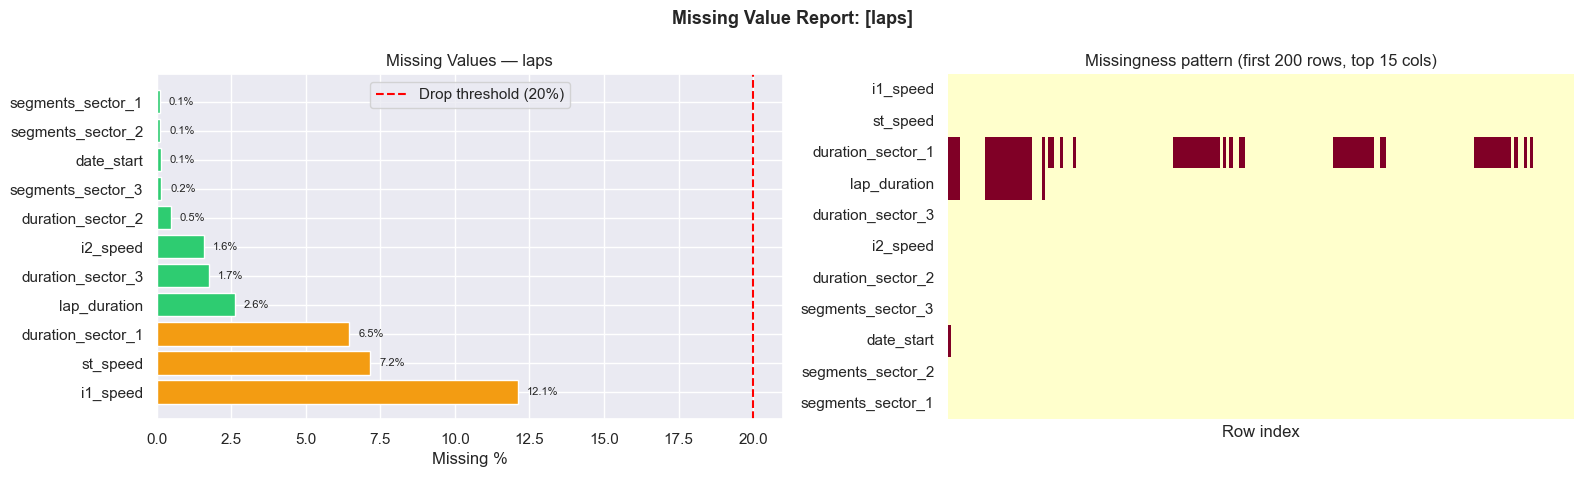

In [6]:
def plot_missing(df: pd.DataFrame, title: str = '', threshold: float = 0.0):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss = miss[miss > threshold]
    if miss.empty:
        print(f'✅ No missing values above {threshold}% threshold')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(miss) * 0.35 + 1)))

    # Bar chart
    colors = ['#e74c3c' if v > HIGH_MISSING_THRESHOLD*100 else '#f39c12' if v > 5 else '#2ecc71'
              for v in miss.values]
    axes[0].barh(miss.index, miss.values, color=colors)
    axes[0].axvline(HIGH_MISSING_THRESHOLD * 100, color='red', linestyle='--', label=f'Drop threshold ({HIGH_MISSING_THRESHOLD*100:.0f}%)')
    axes[0].set_xlabel('Missing %')
    axes[0].set_title(f'Missing Values — {title}')
    axes[0].legend()
    for i, v in enumerate(miss.values):
        axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

    # Heatmap (top 15 cols max)
    top_cols = miss.head(15).index.tolist()
    sample = df[top_cols].head(200).isnull()
    sns.heatmap(sample.T, cmap='YlOrRd', cbar=False, ax=axes[1],
                xticklabels=False, yticklabels=True)
    axes[1].set_title('Missingness pattern (first 200 rows, top 15 cols)')
    axes[1].set_xlabel('Row index')

    plt.suptitle(f'Missing Value Report: [{title}]', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Drop recommendations
    to_drop = miss[miss > HIGH_MISSING_THRESHOLD * 100]
    if not to_drop.empty:
        print(f'\n🔴 Columns to consider DROPPING (>{HIGH_MISSING_THRESHOLD*100:.0f}% missing):')
        display(to_drop.reset_index().rename(columns={'index':'column', 0:'missing_%'}))


if ENDPOINT_TO_PROFILE in dfs:
    plot_missing(dfs[ENDPOINT_TO_PROFILE], title=ENDPOINT_TO_PROFILE, threshold=0)

In [7]:
# Missing overview cho TẤT CẢ endpoints
miss_summary = []
for ep, df in dfs.items():
    miss_pct = df.isnull().mean() * 100
    miss_summary.append({'endpoint': ep, 'rows': len(df),
                          'cols_total': len(df.columns),
                          'cols_any_null': (miss_pct > 0).sum(),
                          'cols_drop_candidate': (miss_pct > HIGH_MISSING_THRESHOLD*100).sum(),
                          'overall_null_%': round(df.isnull().values.mean() * 100, 2)})

miss_df = pd.DataFrame(miss_summary)
print('=== Missing Value Summary (All Endpoints) ===')
display(miss_df.style.background_gradient(cmap='Reds', subset=['overall_null_%', 'cols_drop_candidate']))

=== Missing Value Summary (All Endpoints) ===


,endpoint,rows,cols_total,cols_any_null,cols_drop_candidate,overall_null_%
0,car_data,85151808,23,2,0,0.180000
1,drivers,3717,13,2,1,5.410000
2,intervals,1362164,7,2,0,0.250000
3,laps,81613,17,11,0,1.920000
4,location,43062384,13,0,0,0.000000
5,meetings,180,19,0,0,0.000000
6,overtakes,13661,7,0,0,0.000000
7,pit,7684,9,3,1,13.890000
8,position,111867,6,0,0,0.000000
9,race_control,9253,12,6,6,31.810000


---
## 6️⃣ Deduplication Check

In [9]:
KEY_MAP = {
    'sessions':       ['session_key'],
    'drivers':        ['session_key', 'driver_number'],
    'laps':           ['session_key', 'driver_number', 'lap_number'],
    'stints':         ['session_key', 'driver_number', 'stint_number'],
    'weather':        ['session_key', 'date'],
    'intervals':      ['session_key', 'driver_number', 'date'],
    'starting_grid':  ['session_key', 'driver_number'],
    'session_result': ['session_key', 'driver_number'],
    'meetings':       ['meeting_key'],
}

dup_results = []
for ep, df in dfs.items():
    keys = [k for k in KEY_MAP.get(ep, []) if k in df.columns]
    # Full row duplicates
    full_dups = df.duplicated().sum()
    # Key duplicates
    key_dups = df.duplicated(subset=keys).sum() if keys else None
    dup_results.append({'endpoint': ep, 'total_rows': len(df),
                         'full_row_dups': full_dups,
                         'full_dup_%': round(full_dups/len(df)*100, 2),
                         'key_cols': str(keys),
                         'key_dups': key_dups})

dup_df = pd.DataFrame(dup_results)
print('=== Deduplication Report ===')
display(dup_df.style.background_gradient(cmap='Oranges', subset=['full_dup_%']))

=== Deduplication Report ===


,endpoint,total_rows,full_row_dups,full_dup_%,key_cols,key_dups
0,car_data,85151808,0,0.000000,[],nan
1,drivers,3717,0,0.000000,"['session_key', 'driver_number']",0.000000
2,intervals,1362164,0,0.000000,"['session_key', 'driver_number', 'date']",0.000000
3,laps,81613,0,0.000000,"['session_key', 'driver_number', 'lap_number']",0.000000
4,location,43062384,0,0.000000,[],nan
5,meetings,180,108,60.000000,['meeting_key'],108.000000
6,overtakes,13661,0,0.000000,[],nan
7,pit,7684,0,0.000000,[],nan
8,position,111867,0,0.000000,[],nan
9,race_control,9253,0,0.000000,[],nan


---
## 7️⃣ Datetime Feature Detection & Transformation Check

In [10]:
import re

DATE_PATTERNS = re.compile(r'date|time|start|end|created|updated', re.IGNORECASE)

dt_report = []
for ep, df in dfs.items():
    for col in df.select_dtypes(include='object').columns:
        if DATE_PATTERNS.search(col):
            sample = df[col].dropna().head(3).tolist()
            # Try parsing
            try:
                parsed = pd.to_datetime(df[col].dropna().head(100), errors='coerce')
                parse_rate = parsed.notna().mean() * 100
            except Exception:
                parse_rate = 0
            dt_report.append({'endpoint': ep, 'column': col,
                               'current_dtype': str(df[col].dtype),
                               'parse_success_%': round(parse_rate, 1),
                               'sample': str(sample[:2]),
                               'action': '✅ Convert to datetime' if parse_rate > 80 else '⚠️ Check format'})

if dt_report:
    print('=== Datetime Column Detection ===')
    display(pd.DataFrame(dt_report).style.applymap(
        lambda v: 'background-color: #d4edda' if '✅' in str(v) else
                  'background-color: #fff3cd' if '⚠️' in str(v) else '',
        subset=['action']
    ))
else:
    print('No datetime-like columns detected in object columns')

=== Datetime Column Detection ===


,endpoint,column,current_dtype,parse_success_%,sample,action
0,car_data,_source_endpoint,object,0.000000,"['car_data', 'car_data']",⚠️ Check format
1,drivers,_source_endpoint,object,0.000000,"['drivers', 'drivers']",⚠️ Check format
2,intervals,date,object,100.000000,"['2024-03-02T14:03:46.275000+00:00', '2024-03-02T15:03:44.432000+00:00']",✅ Convert to datetime
3,intervals,_source_endpoint,object,0.000000,"['intervals', 'intervals']",⚠️ Check format
4,laps,date_start,object,100.000000,"['2024-03-01T16:00:16.716000+00:00', '2024-03-01T16:00:22.110000+00:00']",✅ Convert to datetime
5,laps,_source_endpoint,object,0.000000,"['laps', 'laps']",⚠️ Check format
6,location,_source_endpoint,object,0.000000,"['location', 'location']",⚠️ Check format
7,meetings,date_start,object,100.000000,"['2024-02-29T11:30:00+00:00', '2024-02-29T11:30:00+00:00']",✅ Convert to datetime
8,meetings,date_end,object,100.000000,"['2024-03-02T17:00:00+00:00', '2024-03-02T17:00:00+00:00']",✅ Convert to datetime
9,meetings,_source_endpoint,object,0.000000,"['meetings', 'meetings']",⚠️ Check format


---
## 📋 Tổng hợp: Cleaning Recommendations

In [12]:
print('=' * 70)
print('CLEANING STRATEGY SUMMARY')
print('=' * 70)

for ep, df in dfs.items():
    print(f'\n📁 [{ep}]  {len(df):,} rows × {len(df.columns)} cols')

    # Missing
    miss = df.isnull().mean() * 100
    drop_cols = miss[miss > HIGH_MISSING_THRESHOLD * 100].index.tolist()
    impute_cols = miss[(miss > 0) & (miss <= HIGH_MISSING_THRESHOLD * 100)].index.tolist()
    if drop_cols:
        print(f'  🔴 DROP (>{HIGH_MISSING_THRESHOLD*100:.0f}% missing): {drop_cols}')
    if impute_cols:
        print(f'  🟡 IMPUTE: {impute_cols[:5]}{"..." if len(impute_cols)>5 else ""}')

    # Low variance
    lv = [c for c in df.columns if c != '_source_endpoint' and
           df[c].value_counts(normalize=True, dropna=False).iloc[0] >= LOW_VARIANCE_THRESHOLD]
    if lv:
        print(f'  ⚪ LOW VARIANCE (consider drop): {lv}')

    # Duplicates
    dups = df.duplicated().sum()
    if dups > 0:
        print(f'  🟠 DUPLICATES: {dups:,} full-row duplicates')

    # Negative numbers - Safe version using try-except
    neg = {}
    for c in df.select_dtypes(include='number').columns:
        try:
            if df[c].min() < 0:
                neg[c] = (df[c] < 0).sum()
        except TypeError:
            # Bỏ qua nếu cột này không hỗ trợ so sánh < 0 (như Timedelta)
            continue
    
    if neg:
        print(f'  🔴 NEGATIVE VALUES: {neg}')

print('\n' + '=' * 70)
print('Done! Use these findings to tune src/clean_data.py 🚀')
print('=' * 70)


CLEANING STRATEGY SUMMARY

📁 [car_data]  85,151,808 rows × 23 cols
  🟡 IMPUTE: ['DistanceToDriverAhead', 'RelativeDistance']
  ⚪ LOW VARIANCE (consider drop): ['Status']
  🔴 NEGATIVE VALUES: {'Distance': np.int64(18264), 'RelativeDistance': np.int64(18288), 'X': np.int64(36982320), 'Y': np.int64(34348344), 'Z': np.int64(28410768)}

📁 [drivers]  3,717 rows × 13 cols
  🔴 DROP (>20% missing): ['country_code']
  🟡 IMPUTE: ['headshot_url']

📁 [intervals]  1,362,164 rows × 7 cols
  🟡 IMPUTE: ['gap_to_leader', 'interval']

📁 [laps]  81,613 rows × 17 cols
  🟡 IMPUTE: ['date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed']...

📁 [location]  43,062,384 rows × 13 cols
  ⚪ LOW VARIANCE (consider drop): ['Status', 'Source']
  🔴 NEGATIVE VALUES: {'X': np.int64(18629232), 'Y': np.int64(17337696), 'Z': np.int64(14359824)}

📁 [meetings]  180 rows × 19 cols
  🟠 DUPLICATES: 108 full-row duplicates

📁 [overtakes]  13,661 rows × 7 cols

📁 [pit]  7,684 rows × 9 cols
  🔴 DRO